# 🚲 Previsão de Demanda de Bicicletas — Passo a passo guiado

Bem-vindo! Este notebook é um **tour completo e comentado** do projeto. A ideia é que,
ao final, você entenda não só *o que* o código faz, mas principalmente *por que* cada
decisão foi tomada — que é o que diferencia um projeto de ciência de dados profissional
de um amontoado de células soltas.

## O problema

Queremos prever **quantas bicicletas serão alugadas em uma determinada hora**. Esse é um
problema de **regressão** (o alvo é um número contínuo) sobre uma **série temporal** (as
observações estão ordenadas no tempo e têm dependência entre si). É um caso clássico e
muito próximo de problemas reais de negócio: previsão de demanda em logística, varejo,
energia e transporte seguem exatamente a mesma lógica.

## Por que este dataset?

Usamos o [UCI Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset),
público e sem restrições de licença. Ele é rico o suficiente para demonstrar técnicas
avançadas (sazonalidade em múltiplas escalas, efeitos de clima e calendário) e pequeno o
suficiente para rodar em um laptop.

## Como este notebook se relaciona com o código

Nada de lógica "escondida" aqui: o notebook apenas **orquestra e narra**. Toda a lógica
vive no pacote `demand_forecasting` (pasta `src/`), que também é usado pelo script
`scripts/run_pipeline.py` e coberto por testes em `tests/`. Isso é intencional — código
testável fica em módulos; o notebook serve para contar a história.

| Etapa | Módulo usado |
|---|---|
| Carregar dados | `data.py` |
| Criar atributos | `features.py` |
| Dividir, treinar, tunar | `model.py` |
| Avaliar | `evaluate.py` |
| Explicar | `explain.py` |

> 💡 **Como executar:** rode as células na ordem (`Shift+Enter`, ou menu *Run → Run All*).
> A primeira execução baixa o dataset uma única vez.

## 0. Preparação do ambiente

Dois ajustes antes de começar:

1. **`%matplotlib inline`** garante que os gráficos apareçam **dentro** do notebook. Sem
   isso, dependendo do backend ativo, você poderia ver o aviso
   *"FigureCanvasAgg is non-interactive, and thus cannot be shown"* — ele significa apenas
   que o matplotlib estava num modo feito para salvar arquivos, não para exibir na tela.
2. Adicionamos a pasta `src/` ao caminho de importação (`sys.path`), para que o Python
   enxergue o pacote `demand_forecasting` sem precisar instalá-lo.

In [4]:
%matplotlib inline
import sys
from pathlib import Path

# Raiz do projeto: um nível acima de notebooks/ quando aberto a partir dela.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import pandas as pd
import matplotlib.pyplot as plt

from demand_forecasting import config, data, features, model, evaluate, explain

print('Projeto :', PROJECT_ROOT)
print('Alvo    :', config.TARGET, '(total de aluguéis por hora)')
print('Pacote demand_forecasting importado com sucesso.')

Projeto : C:\Doutorado\Portfolio-GitHub\ml-demand-forecasting
Alvo    : cnt (total de aluguéis por hora)
Pacote demand_forecasting importado com sucesso.


## 1. Carregando e limpando os dados

A função `data.load_clean()` faz três coisas importantes nos bastidores:

1. **Baixa o dataset** (só na primeira vez; depois reutiliza o arquivo local). O download
   é robusto a problemas de certificado SSL — se o seu antivírus inspeciona HTTPS
   (ex.: Avast), ele valida pela cadeia de certificados do próprio sistema operacional.
2. **Reconstrói o `timestamp`**: o dataset guarda a data (`dteday`) e a hora (`hr`) em
   colunas separadas; juntamos as duas em um único instante de tempo e ordenamos
   cronologicamente. Toda a parte de série temporal depende dessa ordem.
3. **Remove colunas perigosas**: `casual` + `registered` **somam exatamente** o alvo
   `cnt`. Se deixássemos essas colunas, o modelo "adivinharia" a resposta — isso se chama
   **vazamento de dados** (*data leakage*) e é um dos erros mais comuns e graves em ML.
   Também removemos identificadores (`instant`) e a data textual já convertida.

In [5]:
df = data.load_clean()
print('Formato (linhas, colunas):', df.shape)
print('Período coberto:', df['timestamp'].min(), '->', df['timestamp'].max())
df.head()

Formato (linhas, colunas): (17379, 14)
Período coberto: 2011-01-01 00:00:00 -> 2012-12-31 23:00:00


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,timestamp
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,2011-01-01 00:00:00
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,2011-01-01 01:00:00
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,2011-01-01 02:00:00
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,2011-01-01 03:00:00
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,2011-01-01 04:00:00


Repare nas colunas que sobraram: variáveis de clima (`temp`, `atemp`, `hum`, `windspeed`),
de calendário (`season`, `holiday`, `weekday`, `workingday`, `weathersit`) e o alvo `cnt`.
Vamos conhecer a estatística básica de cada uma antes de modelar.

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
season,17379.0,2.50164,1.0,2.0,3.0,3.0,4.0,1.106918
yr,17379.0,0.502561,0.0,0.0,1.0,1.0,1.0,0.500008
mnth,17379.0,6.537775,1.0,4.0,7.0,10.0,12.0,3.438776
hr,17379.0,11.546752,0.0,6.0,12.0,18.0,23.0,6.914405
holiday,17379.0,0.02877,0.0,0.0,0.0,0.0,1.0,0.167165
weekday,17379.0,3.003683,0.0,1.0,3.0,5.0,6.0,2.005771
workingday,17379.0,0.682721,0.0,0.0,1.0,1.0,1.0,0.465431
weathersit,17379.0,1.425283,1.0,1.0,1.0,2.0,4.0,0.639357
temp,17379.0,0.496987,0.02,0.34,0.5,0.66,1.0,0.192556
atemp,17379.0,0.475775,0.0,0.3333,0.4848,0.6212,1.0,0.17185


## 2. Análise exploratória (EDA)

Antes de qualquer modelo, precisamos **entender a estrutura dos dados**. A EDA não é
enfeite: é o que nos diz quais atributos vale a pena criar. Vamos investigar três
perguntas.

### 2.1 Como a demanda varia ao longo do dia?

Esperamos picos nos horários de deslocamento (ida e volta do trabalho). Se esse padrão
existir, a **hora do dia** será um atributo poderoso.

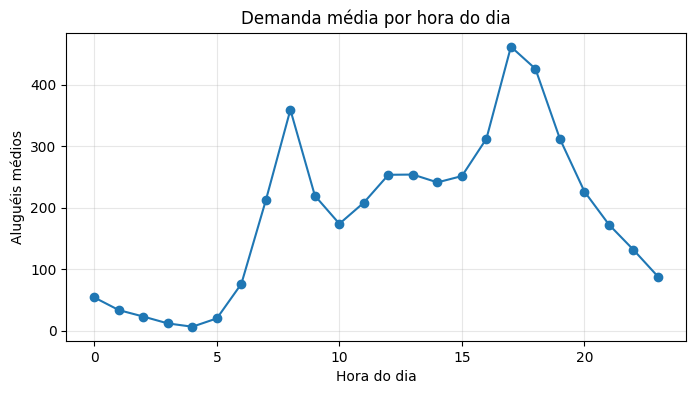

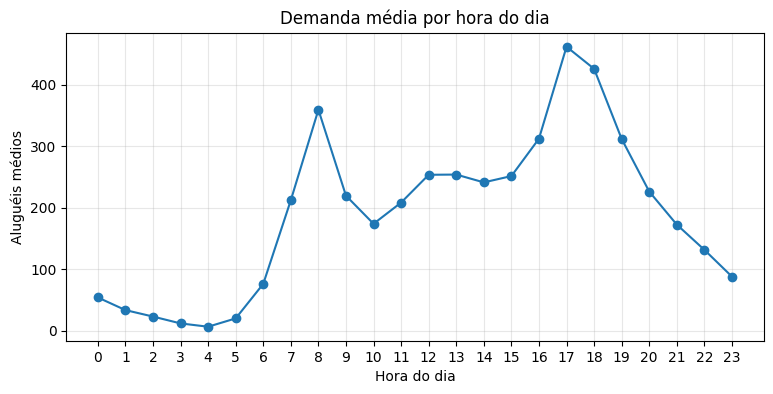

In [7]:
by_hour = df.groupby(df['timestamp'].dt.hour)[config.TARGET].mean()

fig, ax = plt.subplots(figsize=(9, 4))
by_hour.plot(ax=ax, marker='o')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Aluguéis médios')
ax.set_title('Demanda média por hora do dia')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.show()

**Leitura do gráfico:** normalmente aparecem dois picos claros, por volta das 8h e das
17h–18h — exatamente os horários de pico de deslocamento. Isso confirma que a hora do dia
carrega muita informação e justifica criarmos atributos a partir dela.

### 2.2 Dias úteis se comportam diferente de fins de semana?

Se sim, uma simples flag de fim de semana (e a interação com a hora) ajudará o modelo.

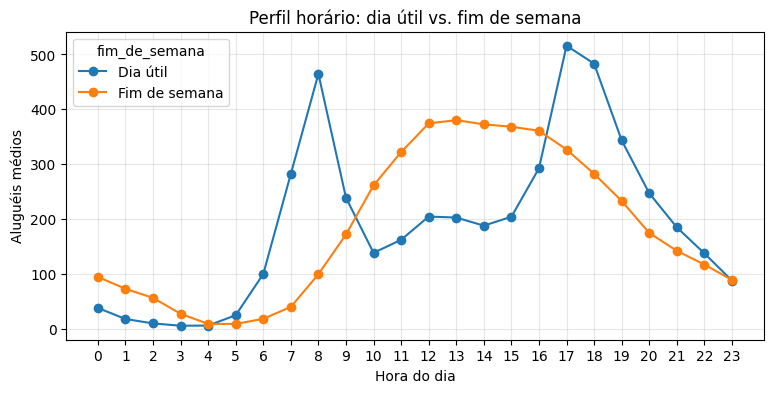

In [8]:
tmp = df.copy()
tmp['hour'] = tmp['timestamp'].dt.hour
tmp['fim_de_semana'] = tmp['timestamp'].dt.dayofweek >= 5
perfil = tmp.groupby(['hour', 'fim_de_semana'])[config.TARGET].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4))
perfil.rename(columns={False: 'Dia útil', True: 'Fim de semana'}).plot(ax=ax, marker='o')
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Aluguéis médios')
ax.set_title('Perfil horário: dia útil vs. fim de semana')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
plt.show()

**Leitura do gráfico:** em dias úteis a curva costuma ter os dois picos de deslocamento;
nos fins de semana ela vira uma "corcova" suave no meio do dia (uso de lazer). São dois
regimes diferentes — ótima notícia, porque dá ao modelo algo concreto para aprender.

### 2.3 Como o alvo está distribuído?

Distribuições muito assimétricas (com cauda longa) afetam a escolha de modelo e de
métrica. Vamos olhar.

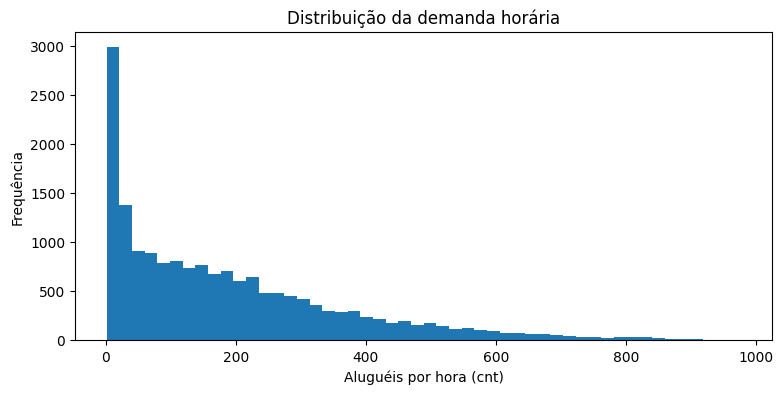

Assimetria (skew): 1.28


In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
df[config.TARGET].plot(kind='hist', bins=50, ax=ax)
ax.set_xlabel('Aluguéis por hora (cnt)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição da demanda horária')
plt.show()

print('Assimetria (skew):', round(df[config.TARGET].skew(), 2))

**Leitura:** a distribuição é assimétrica à direita (muitas horas de baixa demanda e
algumas de demanda muito alta). Modelos baseados em árvores (Random Forest, Gradient
Boosting) lidam bem com isso sem exigir transformação do alvo — mais um motivo para
escolhê-los adiante.

## 3. Engenharia de atributos

Esta é a etapa onde o conhecimento do problema vira variáveis que o modelo entende.
`features.build_features()` aplica **três famílias** de atributos:

### 3.1 Atributos de calendário
Extraímos `hour`, `dayofweek`, `month` e uma flag `is_weekend` do timestamp. São os
ingredientes que a EDA mostrou serem relevantes.

### 3.2 Codificação cíclica (sin/cos) — o truque mais importante aqui
Se representarmos a hora como 0–23, o modelo "pensa" que 23 está longuíssimo de 0. Mas
23h e 0h são **vizinhas**! Para ensinar isso, projetamos cada variável periódica em um
círculo usando seno e cosseno:

$$ hora_{sin} = \sin\left(\frac{2\pi \cdot hora}{24}\right), \qquad hora_{cos} = \cos\left(\frac{2\pi \cdot hora}{24}\right) $$

Assim, 23h e 0h ficam a uma distância mínima no espaço de atributos. Fazemos o mesmo para
dia da semana (período 7) e mês (período 12).

### 3.3 Lags e janelas móveis
A demanda de agora depende da demanda recente. Criamos **lags** (valor de 1h, 2h, 3h, 24h
e 168h = 1 semana atrás) e **médias móveis** das últimas horas. Detalhe crucial: as médias
móveis são **deslocadas em 1 passo** (`shift(1)`) para que o atributo no instante *t*
**nunca** inclua o alvo em *t* — de novo, evitando vazamento.

As primeiras linhas ficam com `NaN` (não há "1 semana atrás" para a primeira semana), então
são descartadas.

In [10]:
feat = features.build_features(df)
print('Antes :', df.shape)
print('Depois:', feat.shape, '(algumas linhas iniciais foram removidas pelos lags)')

novos = [c for c in feat.columns if c not in df.columns]
print('\nAtributos criados ({}):'.format(len(novos)))
for c in novos:
    print('  -', c)

Antes : (17379, 14)
Depois: (17211, 31) (algumas linhas iniciais foram removidas pelos lags)

Atributos criados (17):
  - hour
  - dayofweek
  - month
  - is_weekend
  - hour_sin
  - hour_cos
  - dayofweek_sin
  - dayofweek_cos
  - month_sin
  - month_cos
  - cnt_lag_1
  - cnt_lag_2
  - cnt_lag_3
  - cnt_lag_24
  - cnt_lag_168
  - cnt_rollmean_3
  - cnt_rollmean_24


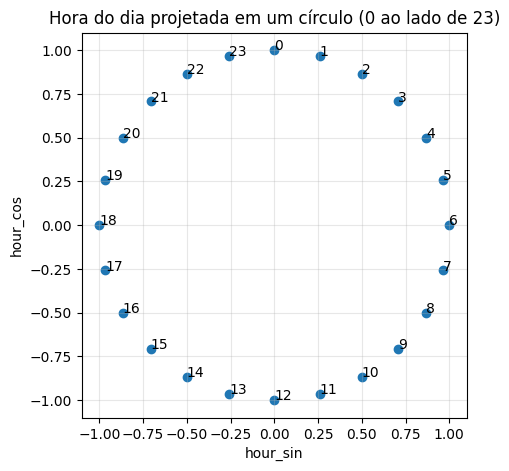

In [11]:
# Visualizando a codificação cíclica da hora: as 24 horas formam um círculo perfeito.
amostra = feat.drop_duplicates('hour').sort_values('hour')
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(amostra['hour_sin'], amostra['hour_cos'])
for _, r in amostra.iterrows():
    ax.annotate(int(r['hour']), (r['hour_sin'], r['hour_cos']))
ax.set_xlabel('hour_sin'); ax.set_ylabel('hour_cos')
ax.set_title('Hora do dia projetada em um círculo (0 ao lado de 23)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.show()

**Leitura:** cada hora é um ponto no círculo e 0 fica logo ao lado de 23. É exatamente
essa "vizinhança" que a codificação cíclica entrega ao modelo.

## 4. Divisão treino/teste — por que **cronológica** e não aleatória

Em dados comuns, embaralhamos antes de dividir. Em **séries temporais, isso é proibido**:
se misturarmos, o modelo treinaria com dados do futuro para prever o passado — algo
impossível na vida real, que infla artificialmente o desempenho (uma forma sutil de
vazamento).

`model.chronological_split()` resolve isso cortando a série no tempo: o começo vira treino
e o final (os últimos 20%) vira teste. Assim avaliamos o modelo como ele será de fato
usado: prevendo o futuro a partir do passado.

In [12]:
split = model.chronological_split(feat)
print('Treino:', split.X_train.shape[0], 'amostras')
print('Teste :', split.X_test.shape[0], 'amostras')
print('Nº de atributos:', split.X_train.shape[1])
print('\nO treino termina e o teste começa no tempo — sem sobreposição nem embaralhamento.')

Treino: 13769 amostras
Teste : 3442 amostras
Nº de atributos: 29

O treino termina e o teste começa no tempo — sem sobreposição nem embaralhamento.


## 5. Treino, tuning e comparação de modelos

Vamos comparar três abordagens, do mais simples ao mais sofisticado:

- **`baseline_mean`** — sempre prevê a média do treino. Não é para "ganhar": é a **régua**.
  Qualquer modelo sério precisa bater o baseline; se não bater, algo está errado.
- **`random_forest`** — floresta de árvores; robusta, captura interações não-lineares.
- **`gradient_boosting`** — árvores em sequência corrigindo o erro umas das outras;
  costuma ser muito competitivo em dados tabulares.

Para os dois modelos de árvore, `model.tune_model()` faz **busca de hiperparâmetros** com
**validação cruzada temporal** (`TimeSeriesSplit`): os folds também respeitam o tempo,
sempre treinando no passado e validando no futuro.

Avaliamos com três métricas:
- **MAE** (erro absoluto médio): erro típico, na mesma unidade do alvo (bicicletas).
- **RMSE** (raiz do erro quadrático médio): penaliza mais os erros grandes.
- **R²**: fração da variância explicada (1 = perfeito; 0 = igual ao baseline).

> ⏱️ Esta é a célula mais demorada (treina e tuna os modelos). Em um laptop típico, leva
> de um a alguns minutos. É normal.

In [13]:
resultados = {}
modelos_treinados = {}

for nome, pipeline in model.build_models().items():
    print(f'Treinando: {nome} ...')
    melhor = model.tune_model(nome, pipeline, split)
    preds = melhor.predict(split.X_test)
    resultados[nome] = evaluate.regression_metrics(split.y_test, preds)
    modelos_treinados[nome] = melhor

ranking = evaluate.leaderboard(resultados)
print('\n=== Ranking (menor RMSE = melhor) ===')
ranking

Treinando: baseline_mean ...
Treinando: random_forest ...
Treinando: gradient_boosting ...

=== Ranking (menor RMSE = melhor) ===


,MAE,RMSE,R2
gradient_boosting,35.833746,54.541749,0.938454
random_forest,32.003303,54.930477,0.937573
baseline_mean,174.204247,231.079185,-0.104753


**Leitura do ranking:** o baseline deve ter R² próximo de 0 (ou negativo), confirmando
que ele não aprende nada — é só a média. Os modelos de árvore devem ficar bem acima,
com R² alto e MAE/RMSE bem menores. A diferença entre eles e o baseline é, na prática, o
**valor que a modelagem agregou**.

## 6. Avaliação do melhor modelo

Métricas resumem o desempenho em um número, mas **gráficos de diagnóstico** revelam *onde*
o modelo erra. Vamos olhar dois.

### 6.1 Real vs. previsto
O ideal é os pontos se alinharem à diagonal vermelha. Desvios sistemáticos (ex.: o modelo
sempre subestima a demanda alta) aparecem como curvatura ou afastamento da linha.

In [ ]:
melhor_nome = ranking.index[0]
melhor_modelo = modelos_treinados[melhor_nome]
preds = melhor_modelo.predict(split.X_test)
print('Melhor modelo:', melhor_nome)
print('Métricas:', resultados[melhor_nome])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(split.y_test, preds, s=8, alpha=0.3)
lims = [min(split.y_test.min(), preds.min()), max(split.y_test.max(), preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Real'); ax.set_ylabel('Previsto')
ax.set_title(f'Real vs. Previsto — {melhor_nome}')
plt.show()

### 6.2 Distribuição dos resíduos
O resíduo é `real - previsto`. Queremos um histograma **centrado em zero** e **simétrico**:
isso indica que o modelo não tem viés sistemático (não erra sempre para o mesmo lado).

In [ ]:
residuos = split.y_test.values - preds
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(residuos, bins=50)
ax.axvline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Resíduo (real - previsto)'); ax.set_ylabel('Frequência')
ax.set_title('Distribuição dos resíduos')
plt.show()

print('Resíduo médio:', round(float(residuos.mean()), 2), '(quanto mais perto de 0, melhor)')

## 7. Explicabilidade — por que o modelo decide o que decide

Um modelo preciso mas inexplicável é difícil de confiar e de defender num ambiente de
negócio. A **importância por permutação** mede quanto o erro do modelo piora quando
embaralhamos uma coluna de cada vez: se embaralhar uma variável destrói o desempenho,
essa variável era importante.

É uma técnica agnóstica ao modelo (funciona para qualquer estimador) e honesta, pois é
medida **no conjunto de teste**.

In [ ]:
importancias = explain.permutation_importances(melhor_modelo, split.X_test, split.y_test)

top = importancias.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'])
ax.set_xlabel('Importância por permutação (aumento no erro)')
ax.set_title('Top 15 atributos mais importantes')
plt.show()

importancias.head(10)

**Leitura:** é comum que os **lags recentes** (demanda 1h e 24h atrás) e a **hora do dia**
dominem o ranking — o que faz todo sentido: a melhor pista para a próxima hora é o passado
imediato e o momento do dia. Isso também valida, na prática, as decisões de engenharia de
atributos tomadas na Seção 3.

## ✅ Conclusão e próximos passos

Percorremos um pipeline completo e **sem vazamento de dados**, da ingestão à
explicabilidade, batendo um baseline honesto com modelos de árvore e interpretando o
resultado. Os pontos de maior valor profissional foram:

- **Divisão cronológica** e **validação cruzada temporal** (respeitar o tempo).
- **Codificação cíclica** para variáveis periódicas.
- **Lags/médias móveis deslocadas** para evitar vazamento.
- **Diagnóstico visual** e **explicabilidade**, não apenas uma métrica isolada.

### Ideias para evoluir o projeto
- Testar modelos de boosting modernos (XGBoost, LightGBM, CatBoost).
- Adicionar validação com janelas deslizantes (*walk-forward*).
- Incorporar `shap` para explicações locais (por previsão) — o módulo `explain.py` já tem
  suporte opcional a SHAP.

### Rodar tudo de uma vez (sem notebook)
```bash
python scripts/run_pipeline.py
```
Gera as métricas e os gráficos na pasta `outputs/`.

### Rodar os testes
```bash
pytest -q
```